In [24]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)

for ticker, df in raw_data.items():
    returns = returns = df["Close"].squeeze().pct_change().dropna() * 100
    print(f"\n{ticker}")
    print(f"  Avg daily return : {returns.mean():.3f}%")
    print(f"  Volatility (std) : {returns.std():.3f}%")
    print(f"  Max single day   : +{returns.max():.2f}%")
    print(f"  Min single day   : {returns.min():.2f}%")
    print(f"  Trading days     : {len(df)}")

print("\nEDA complete. Ready for Phase 4 — Feature Engineering.")

EDA SUMMARY

RELIANCE.NS
  Avg daily return : 0.038%
  Volatility (std) : 1.310%
  Max single day   : +7.02%
  Min single day   : -7.49%
  Trading days     : 741

TCS.NS
  Avg daily return : -0.022%
  Volatility (std) : 1.330%
  Max single day   : +6.63%
  Min single day   : -7.01%
  Trading days     : 741

INFY.NS
  Avg daily return : 0.015%
  Volatility (std) : 1.544%
  Max single day   : +7.93%
  Min single day   : -8.13%
  Trading days     : 741

HDFCBANK.NS
  Avg daily return : 0.003%
  Volatility (std) : 1.229%
  Max single day   : +5.71%
  Min single day   : -8.44%
  Trading days     : 741

WIPRO.NS
  Avg daily return : 0.026%
  Volatility (std) : 1.623%
  Max single day   : +6.60%
  Min single day   : -9.22%
  Trading days     : 741

EDA complete. Ready for Phase 4 — Feature Engineering.


## 6. EDA Summary & Key Findings

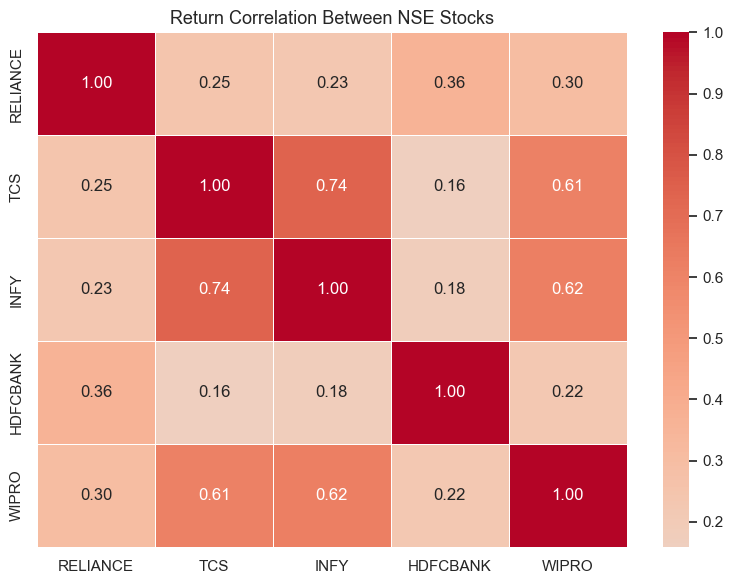

Chart saved.


In [23]:
close_prices = pd.DataFrame({
    ticker: raw_data[ticker]["Close"].squeeze() for ticker in TICKERS
})

correlation = close_prices.pct_change().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5,
    xticklabels=[t.replace(".NS", "") for t in TICKERS],
    yticklabels=[t.replace(".NS", "") for t in TICKERS]
)
plt.title("Return Correlation Between NSE Stocks", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 5. Correlation Between Stocks
Are these stocks moving together? High correlation = less diversification.

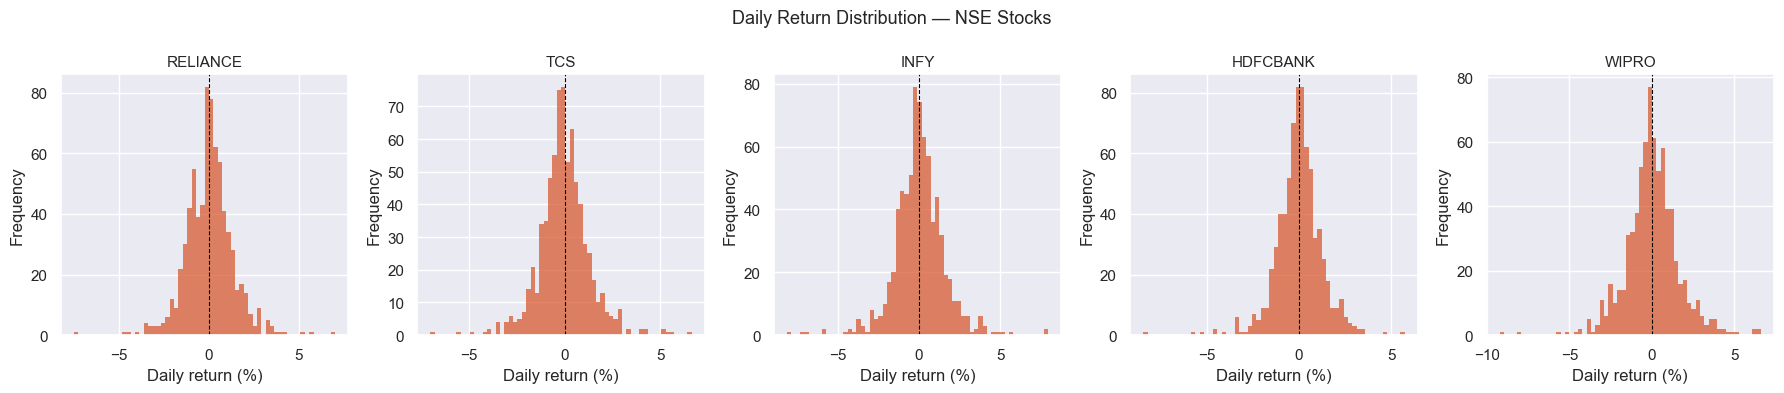

Chart saved.


In [21]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4))

for ax, ticker in zip(axes, TICKERS):
    df = raw_data[ticker].copy()
    df["returns"] = df["Close"].pct_change() * 100
    df["returns"].dropna().plot.hist(
        bins=60, ax=ax, color="#D85A30", alpha=0.75, edgecolor="none"
    )
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(ticker.replace(".NS", ""), fontsize=11)
    ax.set_xlabel("Daily return (%)")

plt.suptitle("Daily Return Distribution — NSE Stocks", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/03_returns_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 4. Daily Returns Distribution
Understanding return distribution helps us spot outliers and volatility.

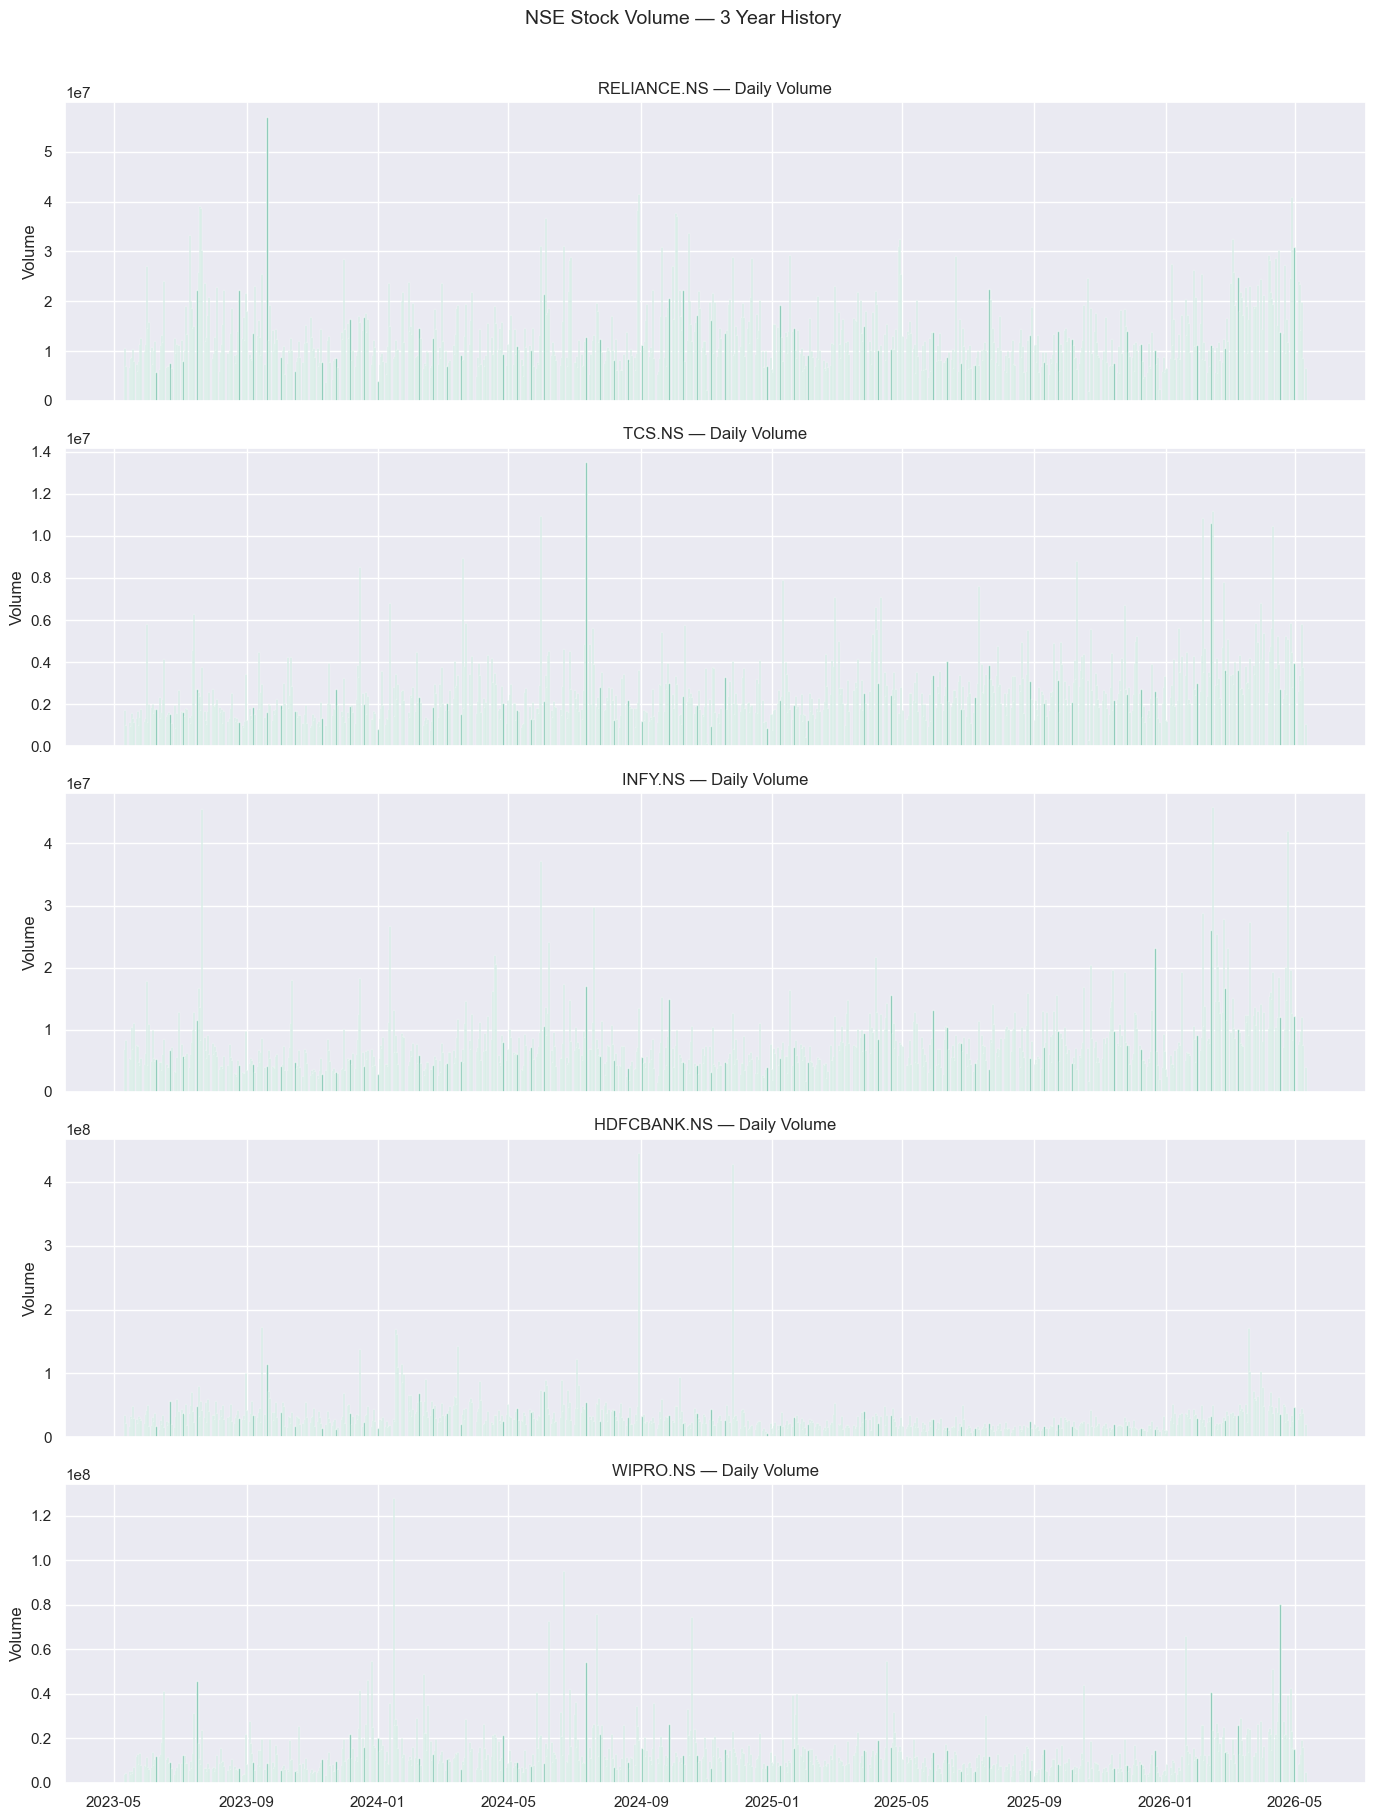

Chart saved.


In [20]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 18), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    df = raw_data[ticker].copy()
    volume = df["Volume"].squeeze().values
    ax.bar(df.index, volume, color="#1D9E75", alpha=0.6, width=1)
    ax.set_title(f"{ticker} — Daily Volume", fontsize=12)
    ax.set_ylabel("Volume")

plt.suptitle("NSE Stock Volume — 3 Year History", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/02_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 3. Volume Analysis
High volume confirms price moves — important context for OB/OS signals.

In [18]:
# Cell 10 — replace df["Volume"] with:
volume = df["Volume"].squeeze()
ax.bar(df.index, volume, color="#1D9E75", alpha=0.6, width=1)

# Cell 12 — replace df["Close"] with:
df["returns"] = df["Close"].squeeze().pct_change() * 100

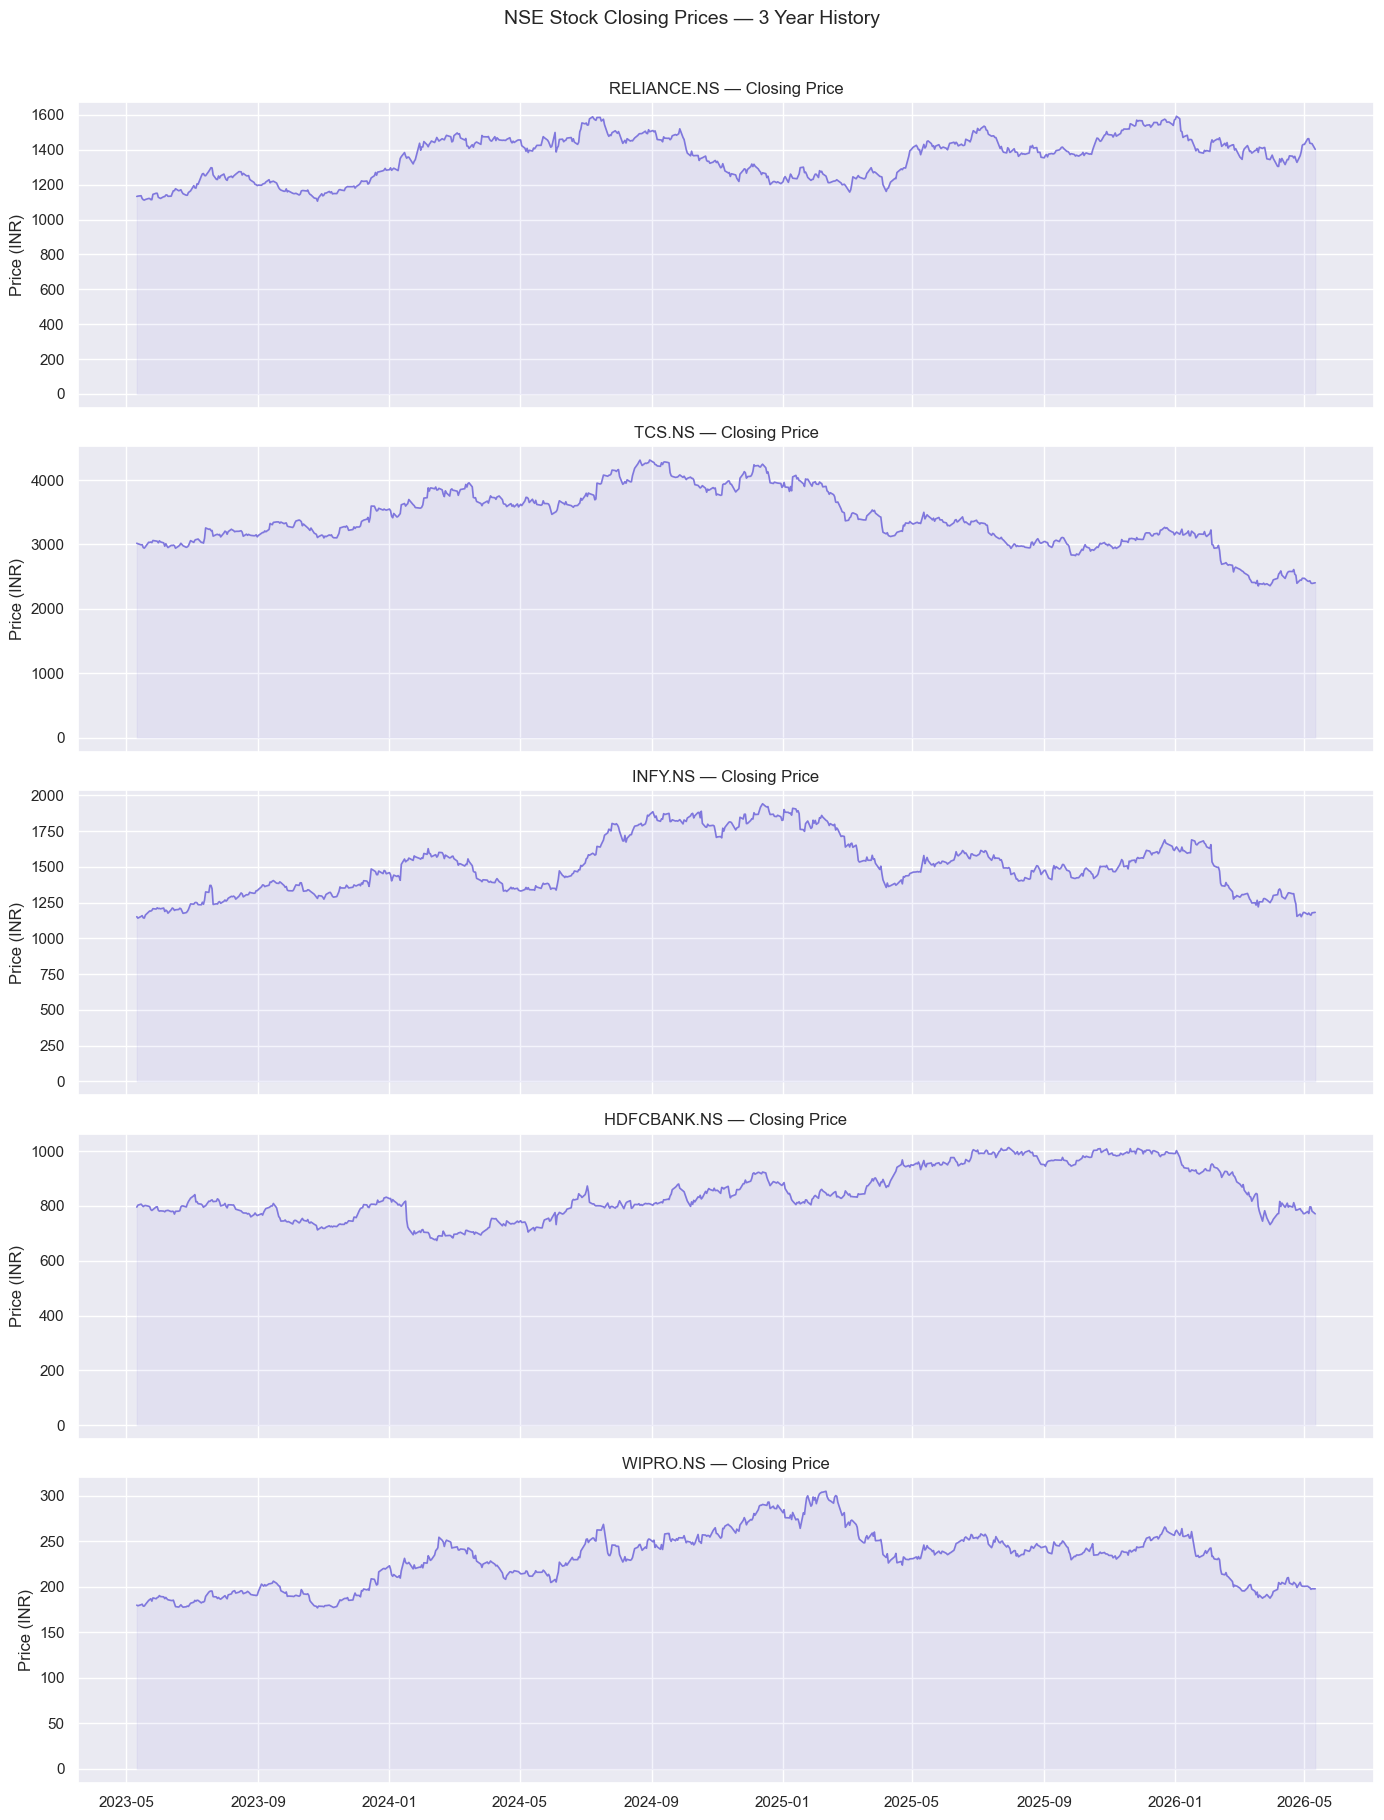

Chart saved.


In [17]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 18), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    df = raw_data[ticker].copy()
    close = df["Close"].squeeze()  # flattens MultiIndex if present
    ax.plot(df.index, close, linewidth=1.2, color="#7F77DD")
    ax.set_title(f"{ticker} — Closing Price", fontsize=12)
    ax.set_ylabel("Price (INR)")
    ax.fill_between(df.index, close, alpha=0.08, color="#7F77DD")

plt.suptitle("NSE Stock Closing Prices — 3 Year History", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/01_closing_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 2. Closing Price Trends
Visualise how each stock has moved over the past 3 years.

In [14]:
for ticker, df in raw_data.items():
    print(f"\n{'='*45}")
    print(f"  {ticker}")
    print(f"{'='*45}")
    print(f"  Shape        : {df.shape}")
    print(f"  Missing vals : {df.isnull().sum().sum()}")
    print(f"  Date range   : {df.index[0].date()} → {df.index[-1].date()}")
    print(f"  Columns      : {list(df.columns)}")
    print(df.describe().T[["mean", "std", "min", "max"]])


  RELIANCE.NS
  Shape        : (741, 5)
  Missing vals : 0
  Date range   : 2023-05-11 → 2026-05-11
  Columns      : [('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]
                          mean        std     min         max
Price  Ticker                                                
Close  RELIANCE.NS     1355.41     123.67 1105.07     1592.30
High   RELIANCE.NS     1367.16     125.07 1116.57     1611.80
Low    RELIANCE.NS     1344.28     122.60 1101.99     1578.20
Open   RELIANCE.NS     1355.74     123.95 1111.07     1593.00
Volume RELIANCE.NS 12906784.29 6581238.81    0.00 57081884.00

  TCS.NS
  Shape        : (741, 5)
  Missing vals : 0
  Date range   : 2023-05-11 → 2026-05-11
  Columns      : [('Close', 'TCS.NS'), ('High', 'TCS.NS'), ('Low', 'TCS.NS'), ('Open', 'TCS.NS'), ('Volume', 'TCS.NS')]
                    mean        std     min         max
Price  Ticker                                   

## 1. Data Quality Check
Check for missing values, data types, and basic shape of each stock.

In [13]:
raw_data = {}

for ticker in TICKERS:
    df = yf.download(ticker, period=PERIOD, auto_adjust=True, progress=False)
    df.dropna(inplace=True)
    raw_data[ticker] = df
    print(f"{ticker:20s} — {len(df)} trading days | {df.index[0].date()} to {df.index[-1].date()}")
    

RELIANCE.NS          — 741 trading days | 2023-05-11 to 2026-05-11
TCS.NS               — 741 trading days | 2023-05-11 to 2026-05-11
INFY.NS              — 741 trading days | 2023-05-11 to 2026-05-11
HDFCBANK.NS          — 741 trading days | 2023-05-11 to 2026-05-11
WIPRO.NS             — 741 trading days | 2023-05-11 to 2026-05-11


In [12]:
TICKERS = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "WIPRO.NS"
]

PERIOD = "3y"   # 3 years of daily data

print(f"Analysing {len(TICKERS)} Nifty 50 stocks over {PERIOD}")

Analysing 5 Nifty 50 stocks over 3y


In [10]:
pip install yfinance

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.3 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   ----- ----------------------------------  3/21 [websockets]
   ----- ----------------------------------  3/21 [websockets]
   ----- ----------------------------------  3/21 [websockets]
   ----- ----------------------------------  3/21 [websockets]
   ----- ---------------

In [8]:
pip install matplotlib seaborn numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 4.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.2 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 3.6 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 3.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 3.2 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 2.9 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 2.9 MB/s eta 0:00:02
   ------------------------ ---------------

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="darkgrid")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [6]:

pip install pandas

  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.7 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.7 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.7 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.7 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.7 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.7 MB 1.1 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.7 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.7 MB 1.2 MB/s eta 0:00:06
   ----------- -----------------------

# 01 — Exploratory Data Analysis
## Stock Overbought / Oversold Detection — NSE/BSE
**Author:** Shanu Kumar Sah  
**Date:** May 2026  
**Goal:** Understand the structure, quality, and distribution of NSE stock data before modelling.